### Contexto e Objetivo

Está sendo desenvolvido um modelo de classificação de dados em uma base de serviço para avaliar se um cliente irá continuar no serviço ou irá cancelá-lo. Essa analise poderá ser util para identificar as chances do cliente querer desistir do serviço que possui, e avaliar os fatores que podem afetar nessa decisão


Importação de Dependências

In [1]:
from functions import gini_coeficient

import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 

import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import PrecisionRecallDisplay

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

In [2]:
df_credit = pd.read_csv(r"..\\documents\\Credit_Card_Churn.csv")

# Análise Inicial da base de Crédito

In [3]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  object 
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  object 
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  object 
 6   Marital_Status            10000 non-null  object 
 7   Income_Category           10000 non-null  object 
 8   Card_Category             10000 non-null  object 
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_R

Análise de valores únicos

In [4]:
for x in df_credit.columns:
    print(f'Coluna: {x}')
    print(np.sort(df_credit[x].unique()), "\n")
    

Coluna: CLIENTNUM
[100000000 100000001 100000002 ... 100009997 100009998 100009999] 

Coluna: Attrition_Flag
['Attrited Customer' 'Existing Customer'] 

Coluna: Customer_Age
[26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 

Coluna: Gender
['F' 'M'] 

Coluna: Dependent_count
[0 1 2 3 4 5] 

Coluna: Education_Level
['College' 'Doctorate' 'Graduate' 'High School' 'Post-Graduate'
 'Uneducated'] 

Coluna: Marital_Status
['Divorced' 'Married' 'Single'] 

Coluna: Income_Category
['$120K +' '$40K - $60K' '$60K - $80K' '$80K - $120K' 'Less than $40K'
 'Unknown'] 

Coluna: Card_Category
['Blue' 'Gold' 'Platinum' 'Silver'] 

Coluna: Months_on_book
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60] 

Coluna: Total_Relationship_Count
[1 2 3 4 5 6] 

Coluna: Months_Inactive_12_mon
[0 1 2 3 4 5 6] 

Coluna: 

Avaliar se o dataset apresenta valores numéricos abaixo de 0

In [5]:
colunas_numericas = [c for c in df_credit.columns if df_credit[c].dtype != 'object']

print("Colunas com valores abaixo de 0:\n")

for c in colunas_numericas:
    if (df_credit[c] < 0).any():
        print(c)


Colunas com valores abaixo de 0:

Avg_Open_To_Buy


In [6]:
# Análise percentual de clientes que cancelaram o cartão de crédito

df_credit['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.85
Attrited Customer    0.15
Name: proportion, dtype: float64

In [7]:
# Análise percentual de clientes que cancelaram o cartão de crédito por tipo de cartão

df_credit.groupby("Card_Category")['Attrition_Flag'].value_counts(normalize=True)

Card_Category  Attrition_Flag   
Blue           Existing Customer    0.84
               Attrited Customer    0.16
Gold           Existing Customer    0.87
               Attrited Customer    0.13
Platinum       Existing Customer    0.90
               Attrited Customer    0.10
Silver         Existing Customer    0.86
               Attrited Customer    0.14
Name: proportion, dtype: float64

Adaptação dos Dados

Nessa estapa está sendo adaptado as colunas em string para padrões numérico para avaliar o quanto elas se correlacionam entre si e então avaliar quais podem ser descartadas no modelo

In [8]:
df_base_credit = df_credit.copy()

income_category_map = {"Less than $40K": 1, "$40K - $60K": 2,
                       "$60K - $80K": 3, "$80K - $120K": 4, "$120K +": 5} # "Unknown": 0,

atrition_flag_map = {
    'Attrited Customer': 0,
    'Existing Customer': 1
}

df_base_credit['Is_Male'] = df_base_credit['Gender'].map(lambda x: x == 'M').astype("int")
df_base_credit['Is_Female'] = df_base_credit['Gender'].map(lambda x: x == 'F').astype("int")

df_base_credit['Attrition_Flag'] = df_base_credit['Attrition_Flag'].map(atrition_flag_map).astype("int")


df_base_credit['Income_Category'] = df_base_credit['Income_Category'].map(income_category_map)

# foi calculado a mediana pois com o valor Unknown daria a entender que seria o menor renda possivel
mediana_income_category = df_base_credit['Income_Category'].median()

df_base_credit['Income_Category'] = df_base_credit['Income_Category'].fillna(mediana_income_category).astype("int")


df_base_credit['Is_Uneducated'] = df_base_credit['Education_Level'].map(lambda x: x == 'Uneducated').astype("int")

df_base_credit['Education_HighSchool'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'High School'
                                                                        ).astype("int")

df_base_credit['Education_College'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'College'
                                                                        ).astype("int")

df_base_credit['Education_Graduate'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'Graduate'
                                                                        ).astype("int")

df_base_credit['Education_Post_Graduate'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'Post-Graduate'
                                                                        ).astype("int")

df_base_credit['Education_Doctorate'] = df_base_credit['Education_Level'].map(
                                                                            lambda x: x == 'Doctorate'
                                                                        ).astype("int")


df_base_credit['Status_Divorced'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Divorced').astype("int")
df_base_credit['Status_Single'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Single').astype("int")
df_base_credit['Status_Married'] = df_base_credit['Marital_Status'].map(lambda x: x == 'Married').astype("int")

df_base_credit['Is_Blue_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Blue').astype("int")
df_base_credit['Is_Silver_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Silver').astype("int")
df_base_credit['Is_Gold_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Gold').astype("int")
df_base_credit['Is_Platinum_Card'] = df_base_credit['Card_Category'].map(lambda x: x == 'Platinum').astype("int")


Validação das colunas com alta correlação com o target

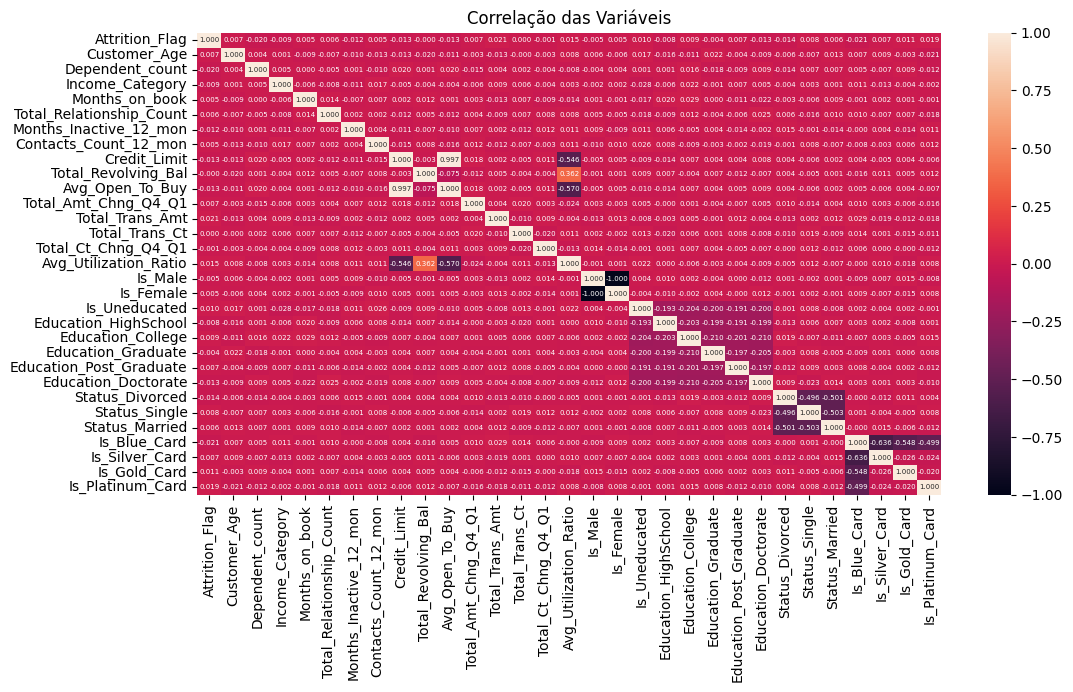

In [9]:
base_correlacao = df_base_credit.drop(columns=['Gender', 'CLIENTNUM', 
                                               'Marital_Status', 'Card_Category', 
                                               'Education_Level']).corr()

plt.figure(figsize=(12, 6))

sns.heatmap(data=base_correlacao, 
            annot=True, fmt=".3f", annot_kws={"size": 5})
plt.title("Correlação das Variáveis")
plt.show()

Conlusões

* A coluna CLIENTNUM será removida pois apresenta valores constantes, 
  atrapalhando na classificação dos dados

* A coluna Avg_Open_To_By é o calculo do credito limite menos
  o valor que fo utilizado, é matematicamente identico ao Credit_Limit

* Pelo dataset apresentar vários atributos One-Hot-Enconding, poderia
  confundir os modelos para o tratamento, então teria que adaptar para 
  recuperar os casos relacionados a valores que mudam constantemente


In [10]:
df_credit_clean = df_base_credit.drop(columns=['CLIENTNUM', 'Gender', 'Marital_Status', 
                                              'Card_Category', 'Is_Female', 'Status_Divorced',
                                              'Avg_Open_To_Buy', 'Education_Level',

                                              'Is_Male',
                                              'Is_Uneducated', 
                                              'Education_HighSchool', 'Education_College',
                                              'Education_Graduate', 'Education_Post_Graduate', 'Education_Doctorate',
                                              
                                              'Income_Category',

                                              'Status_Single', 'Status_Married',
                                              'Is_Blue_Card', 'Is_Silver_Card', 'Is_Gold_Card', 'Is_Platinum_Card'
                                            ])


In [11]:
df_credit_clean.columns

Index(['Attrition_Flag', 'Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

Definição das variáveis de treino e teste

In [12]:
X = df_credit_clean.drop(columns=['Attrition_Flag'], axis=1)
y = df_credit_clean['Attrition_Flag']

# Será dividido os dados dos eixos x e y em 80% de treino e 20% de teste
# stratify -> variável alvo
# random_state -> trava o sorteio para ser sempre igual

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

# Modelo de Regressão Logística

In [13]:
# Deve ser aplicado o StandardScaler para que o Modelo de Regressão Logística
# consiga colocar todas as variáveis na mesma escala

scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [14]:
# Modelo Logistic Regression

# criação do modelo
logistic_regression = LogisticRegression(class_weight='balanced', max_iter=2000)

# treinamento do modelo
logistic_regression.fit(X_train_scalled, Y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [15]:
# Obtenção de Probabilidades (importante para o Gini), 
# Será pego a probabilidade de Churn (classe 1)
prob_lr = logistic_regression.predict_proba(X_test_scalled)[:, 1]


# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_lr = gini_coeficient(Y_test, prob_lr)

print(f'Coeficiente de Gini (Logistic Regression): {gini_lr}')

Coeficiente de Gini (Logistic Regression): 0.09012234810107134


# Avaliação do Limite apropriado

para avaliar o limite de dados adequado para comparar na matriz de confusão
será testado um grupo de limites de 0 a 1 identificando qual intervalo seria mais apropriado


In [16]:
# Previsão do modelo
pred_lr = logistic_regression.predict(X_test_scalled)

print(f"Matriz de Confusão (Logistic Regression):\n{confusion_matrix(Y_test, pred_lr)}\n")

print(f"Relatório Logistic Regression:\n {
                classification_report(Y_test, pred_lr, target_names=['Churn', 'Permaneceu'], zero_division=0)
            }")


Matriz de Confusão (Logistic Regression):
[[180 128]
 [882 810]]

Relatório Logistic Regression:
               precision    recall  f1-score   support

       Churn       0.17      0.58      0.26       308
  Permaneceu       0.86      0.48      0.62      1692

    accuracy                           0.49      2000
   macro avg       0.52      0.53      0.44      2000
weighted avg       0.76      0.49      0.56      2000



In [21]:
# Comparativo com os Limites do Logistic Regression

for l in np.arange(0.1, 1, 0.1):
    print(f"Matriz de Correlação - Limite {l}".format("%.2f"))
    print(confusion_matrix(Y_test, (prob_lr > l).astype("int") ))
    print("\n")


Matriz de Correlação - Limite 0.1
[[   0  308]
 [   0 1692]]


Matriz de Correlação - Limite 0.2
[[   0  308]
 [   0 1692]]


Matriz de Correlação - Limite 0.30000000000000004
[[   0  308]
 [   0 1692]]


Matriz de Correlação - Limite 0.4
[[   0  308]
 [   0 1692]]


Matriz de Correlação - Limite 0.5
[[180 128]
 [882 810]]


Matriz de Correlação - Limite 0.6
[[ 308    0]
 [1691    1]]


Matriz de Correlação - Limite 0.7000000000000001
[[ 308    0]
 [1692    0]]


Matriz de Correlação - Limite 0.8
[[ 308    0]
 [1692    0]]


Matriz de Correlação - Limite 0.9
[[ 308    0]
 [1692    0]]




Com base nas apresentações do modelo, o intevalo mais apropriado seria de 0.55

In [ ]:
pred_proba_lr = (prob_lr > 0.55).astype("int")

print(f"Matriz de Confusão (Logistic Regression):\n{confusion_matrix(Y_test, pred_proba_lr)}\n")

print(f"Relatório Logistic Regression:\n {
                classification_report(Y_test, pred_proba_lr, 
                                      target_names=['Churn', 'Permaneceu'], zero_division=0)
            }")


Matriz de Confusão (Logistic Regression):
[[ 303    5]
 [1653   39]]

Relatório Logistic Regression:
               precision    recall  f1-score   support

       Churn       0.15      0.98      0.27       308
  Permaneceu       0.89      0.02      0.04      1692

    accuracy                           0.17      2000
   macro avg       0.52      0.50      0.16      2000
weighted avg       0.77      0.17      0.08      2000



In [56]:
# Análise de quais colunas estão afetando o Modelo

df_importancia = pd.DataFrame({
    'Importância': logistic_regression.coef_[0]  
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna')

df_importancia

,Coluna,Importância
0,Avg_Utilization_Ratio,5.17e-02
1,Total_Trans_Amt,3.87e-02
2,Total_Relationship_Count,1.50e-02
3,Total_Amt_Chng_Q4_Q1,1.39e-02
4,Customer_Age,9.20e-03
5,Months_on_book,8.27e-03
6,Total_Ct_Chng_Q4_Q1,7.71e-03
7,Contacts_Count_12_mon,3.49e-03
8,Credit_Limit,1.47e-03
9,Total_Trans_Ct,-7.54e-03


# Random Florest

In [ ]:
# Modelo Random Florest

# criação do modelo
random_florest = RandomForestClassifier(
    n_estimators=100, # quantidade de estimativas
    max_depth=8, # impede que os dados sejam decorados
    class_weight='balanced', # balanceamento de pesos
    random_state=42
) 

# treinar o modelo
random_florest.fit(X_train, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [82]:
# Obtenção de Probabilidades (importante para o Gini), 
# Será pego a probabilidade de Churn (classe 1)
prob_rf = random_florest.predict_proba(X_test)[:, 1]

# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_rf = gini_coeficient(Y_test, prob_rf)

print(f'Coeficiente de Gini (Random Florest): {gini_rf}')

Coeficiente de Gini (Random Florest): -0.016429492493322262


In [ ]:
# Previsão do modelo

#pred_rf = random_florest.predict(X_test)
pred_rf = (prob_rf < 0.75).astype("int") 

print(f"Matriz de Confusão (Random Florest):\n{confusion_matrix(Y_test, pred_rf  )}\n")

print(f"Relatório Random Florest:\n {
                classification_report(
                    Y_test, pred_rf, target_names=['Churn', 'Permaneceu'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )
            }")


Matriz de Confusão (Random Florest):
[[  33  275]
 [ 169 1523]]

Relatório Random Florest:
               precision    recall  f1-score   support

       Churn       0.16      0.11      0.13       308
  Permaneceu       0.85      0.90      0.87      1692

    accuracy                           0.78      2000
   macro avg       0.51      0.50      0.50      2000
weighted avg       0.74      0.78      0.76      2000



In [60]:
df_importancia = pd.DataFrame({
    'Importância': random_florest.feature_importances_  
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna')

df_importancia

,Coluna,Importância
0,Credit_Limit,0.11
1,Total_Amt_Chng_Q4_Q1,0.11
2,Total_Trans_Amt,0.11
3,Total_Revolving_Bal,0.11
4,Total_Ct_Chng_Q4_Q1,0.09
5,Total_Trans_Ct,0.09
6,Customer_Age,0.08
7,Months_on_book,0.08
8,Avg_Utilization_Ratio,0.07
9,Contacts_Count_12_mon,0.04


# XGBOOT Classifier

In [61]:
# criação do modelo
xgboot_classifier = xgb.XGBClassifier(scale_pos_weight=5.5,  # incluir mais 5.5 de peso ao churn
                                       random_state=42) 

# treinamento do modelo
xgboot_classifier.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [62]:
# Obtenção de Probabilidades (importante para o Gini), 
# Será pego a probabilidade de Churn (classe 1)
prob_xgboot = xgboot_classifier.predict_proba(X_test)[:, 1]

# Coeficiente de Gini
# caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
# se for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

gini_xgboot = gini_coeficient(Y_test, prob_xgboot)

print(f'Coeficiente de Gini (XGBOOST Classifier): {gini_xgboot}')

Coeficiente de Gini (XGBOOST Classifier): 0.018620859046390992


In [78]:
# Teste de vários modelos para avaliar qual "destrava a matriz"
for limit in np.arange(0, 1, 0.1):
    print(f"-- Matriz Limite {limit}--")
    print(confusion_matrix(Y_test, (prob_xgboot > limit).astype(int)))

-- Matriz Limite 0.0--
[[   0  308]
 [   0 1692]]
-- Matriz Limite 0.1--
[[   0  308]
 [   0 1692]]
-- Matriz Limite 0.2--
[[   0  308]
 [   0 1692]]
-- Matriz Limite 0.30000000000000004--
[[   0  308]
 [   1 1691]]
-- Matriz Limite 0.4--
[[   1  307]
 [   3 1689]]
-- Matriz Limite 0.5--
[[   2  306]
 [   4 1688]]
-- Matriz Limite 0.6000000000000001--
[[   3  305]
 [   9 1683]]
-- Matriz Limite 0.7000000000000001--
[[   6  302]
 [  19 1673]]
-- Matriz Limite 0.8--
[[  14  294]
 [  53 1639]]
-- Matriz Limite 0.9--
[[  36  272]
 [ 171 1521]]


In [63]:
# Previsão do modelo
#pred_xgboot = xgboot_classifier.predict(X_test)
pred_xgboot = (prob_xgboot < 0.75).astype("int") 

print(f"Matriz de Confusão:\n{confusion_matrix(Y_test, pred_xgboot)}\n")

print(f"Relatório XGBOOST Classifier:\n {
                classification_report(
                    Y_test, pred_xgboot, target_names=['Churn', 'Permaneceu'],
                    zero_division=0
                )
            }")


Matriz de Confusão:
[[ 299    9]
 [1658   34]]

Relatório XGBOOST Classifier:
               precision    recall  f1-score   support

       Churn       0.15      0.97      0.26       308
  Permaneceu       0.79      0.02      0.04      1692

    accuracy                           0.17      2000
   macro avg       0.47      0.50      0.15      2000
weighted avg       0.69      0.17      0.07      2000



In [64]:
df_importancia = pd.DataFrame({
    'Importância': xgboot_classifier.feature_importances_  
    }, index=X_train.columns
).sort_values(by='Importância', ascending=False).reset_index(names='Coluna')

df_importancia

,Coluna,Importância
0,Total_Revolving_Bal,0.08
1,Credit_Limit,0.08
2,Total_Amt_Chng_Q4_Q1,0.08
3,Contacts_Count_12_mon,0.08
4,Customer_Age,0.08
5,Months_Inactive_12_mon,0.08
6,Months_on_book,0.08
7,Total_Trans_Ct,0.08
8,Total_Relationship_Count,0.08
9,Total_Ct_Chng_Q4_Q1,0.08
